In [6]:
import sys
!{sys.executable} -m pip install -U numpy==1.26.4
!{sys.executable} -m pip install -U torchaudio
!{sys.executable} -m pip install -q lpips facenet-pytorch pytorch-msssim insightface onnxruntime
!{sys.executable} -m pip install Pillow==9.5.0

  Using cached torchaudio-2.11.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (6.9 kB)
Using cached torchaudio-2.11.0-cp312-cp312-manylinux_2_28_x86_64.whl (1.8 MB)
  Attempting uninstall: torchaudio
    Found existing installation: torchaudio 2.5.1+cu121
    Uninstalling torchaudio-2.5.1+cu121:
      Successfully uninstalled torchaudio-2.5.1+cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 MB 11.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for Pillow: filename=Pillow-9.5.0-cp312-cp312-linux_x86_64.whl size=1210292 sha256=d2c116be13bbe17c58312cec8cc496221d4f3e88c81ea75c44cbe319725dbb0b
  Stored in directory: /root/.cache/pip/wheels/ea/de/2e/75a6399e5d8cd3a55c13c8f0658d996d4ce4cff37389de044c
Successfully built Pillow
  Attempting uninstall: Pillow
    Found existing installation: pillow 10.2.0
    Uninstalling pillow-10.2.0:
      Successfully uninstalled pillow-10.2.0
ERROR: pip's dependency resolver does not currently take into account all

In [8]:
# Clean and reinstall
!pip uninstall -y torchvision torchaudio

# Install compatible versions
!pip install torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Found existing installation: torchvision 0.17.2
Uninstalling torchvision-0.17.2:
  Successfully uninstalled torchvision-0.17.2
Found existing installation: torchaudio 2.11.0
Uninstalling torchaudio-2.11.0:
  Successfully uninstalled torchaudio-2.11.0
Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download-r2.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp312-cp312-linux_x86_64.whl (7.3 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchaudio-2.5.1%2Bcu121-cp312-cp312-linux_x86_64.whl (3.4 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp312-cp312-linux_x86_64.whl (780.4 MB)
  Using cached https://download.pytorch.org/whl/cu121/nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl (664.8 MB)
  Using cached https://download.pytorch.org/whl/nvidia_nccl_cu12-2.21.5-py3-none-manylinux2014_x86_64.whl (188.7 MB)
  Attempting uninstall: nvidia-nccl-cu12
    Found existing installation: nvidia-nccl-cu

In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Create a folder for your project
import os
SAVE_DIR = '/content/drive/MyDrive/face_anonymization'
os.makedirs(SAVE_DIR, exist_ok=True)

print("Mounted Google Drive at:", SAVE_DIR)


Mounted at /content/drive
Mounted Google Drive at: /content/drive/MyDrive/face_anonymization


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, Subset
import lpips
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from collections import defaultdict
from facenet_pytorch import InceptionResnetV1
from PIL import Image
import os
import pickle
import random
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [2]:
CFG = {
    'image_size': 112, 'epsilon': 0.03,
    'frequencies': [1,2,4,8], 'k_softplus': 2.0,
    'target_cos': 0.0, 'lambda_util': 5.0,
    'lr': 0.05, 'max_iter': 200,
    'ssim_threshold': 0.85, 'seed': 42,
}

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data

In [4]:
!kaggle datasets download -d jessicali9530/celeba-dataset
!unzip -q celeba-dataset.zip

!kaggle datasets download -d jessicali9530/lfw-dataset
!unzip -q lfw-dataset.zip

import os

print("Content folder:")
print(os.listdir("/content"))

print("\nCelebA folder:")
print(os.listdir("/content/img_align_celeba")[:5])

print("\nLFW folder:")
print(os.listdir("/content/lfw-deepfunneled")[:5])

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
100% 1.33G/1.33G [00:18<00:00, 77.2MB/s]

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/lfw-dataset
License(s): other
100% 112M/112M [00:00<00:00, 171MB/s]

Content folder:
['.config', 'peopleDevTrain.csv', 'mismatchpairsDevTest.csv', 'lfw-deepfunneled', 'matchpairsDevTest.csv', 'peopleDevTest.csv', 'lfw_readme.csv', 'pairs.csv', 'list_bbox_celeba.csv', 'list_eval_partition.csv', 'lfw_allnames.csv', 'mismatchpairsDevTrain.csv', 'img_align_celeba', 'list_attr_celeba.csv', 'drive', 'lfw-dataset.zip', 'list_landmarks_align_celeba.csv', 'celeba-dataset.zip', 'people.csv', 'matchpairsDevTrain.csv', 'sample_data']

CelebA folder:
['img_align_celeba']

LFW folder:
['lfw-deepfunneled']


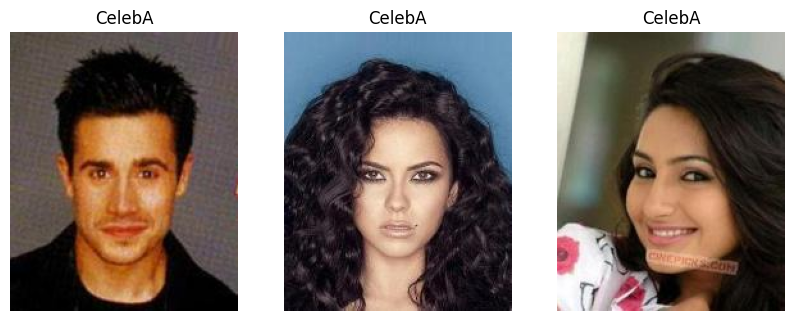

In [5]:
import matplotlib.pyplot as plt
from PIL import Image
import random

# Show 3 CelebA images
celeba_path = "/content/img_align_celeba/img_align_celeba"

imgs = os.listdir(celeba_path)
sample = random.sample(imgs, 3)

plt.figure(figsize=(10,4))
for i, img_name in enumerate(sample):
    img = Image.open(os.path.join(celeba_path, img_name))
    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title("CelebA")
    plt.axis('off')
plt.show()

# Model importing

In [6]:
from insightface.app import FaceAnalysis

surrogate = InceptionResnetV1(pretrained='vggface2', classify=False, device=device).eval()
for p in surrogate.parameters(): p.requires_grad = False

bb1 = InceptionResnetV1(pretrained='casia-webface', classify=False, device=device).eval()
for p in bb1.parameters(): p.requires_grad = False

app_cos = FaceAnalysis(name='buffalo_l'); app_cos.prepare(ctx_id=0, det_size=(640,640))
app_mobile = FaceAnalysis(name='buffalo_s'); app_mobile.prepare(ctx_id=0, det_size=(640,640))

lpips_fn = lpips.LPIPS(net='alex').to(device).eval()

print("Models loaded")

  0%|          | 0.00/107M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/facenet_pytorch/models/inception_resnet_v1.py:329: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(cached_file)

  0%|          | 0.00/111M [00:00<?, ?B/s]

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:03<00:00, 73636.19KB/s]
/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:149: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


...

100%|██████████| 124617/124617 [00:01<00:00, 82083.24KB/s]


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_s/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_s/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_s/det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_s/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_s/w600k_mbf.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
Setting up 

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:03<00:00, 62.9MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Models loaded


/usr/local/lib/python3.12/dist-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(model_path, map_location='cpu'), st

# Core function

## Sinusoidal Perturbation Initialization

$$P_{init}(i,j) = \sum_{k=1}^{K} A_k \cdot \sin(\omega_k \cdot r(i,j) + \phi_k)$$

- $r(i,j) = \sqrt{x^2 + y^2}$ — radial distance from center
- $\omega_k \in \{1, 2, 4, 8\}$ — spatial frequencies
- $A_k$ — random amplitude, $\phi_k$ — random phase

**Why:** Smooth, band-limited start preserves SSIM from first iteration.

In [11]:
def sinusoidal_noise(shape, device='cpu'):
    B, C, H, W = shape
    y = torch.linspace(-1, 1, H, device=device)
    x = torch.linspace(-1, 1, W, device=device)
    yy, xx = torch.meshgrid(y, x, indexing='ij')
    r = torch.sqrt(yy**2 + xx**2)
    noise = torch.zeros(B, C, H, W, device=device)
    for w in [1, 2, 4, 8]:
        phi = torch.rand(B, C, 1, 1, device=device) * 2 * np.pi
        amp = torch.rand(B, C, 1, 1, device=device) / 4
        noise += amp * torch.sin(w * np.pi * r.unsqueeze(0).unsqueeze(0) + phi)
    return noise / noise.abs().max() * 0.0005

## Evaluation Metrics

**Cosine Similarity:** $\cos(z_I, z_A) = \frac{z_I \cdot z_A}{||z_I|| \cdot ||z_A||}$

Lower = better privacy. $\cos < 0$ = different identity.

**SSIM:** $\text{SSIM}(I,A) \in [0,1]$, higher = better visual quality. Target: $> 0.85$.

In [14]:
def cos_sim(x, y):
    return (F.normalize(x, dim=-1) * F.normalize(y, dim=-1)).sum(dim=-1)

def compute_ssim(img1, img2):
    a = img1.squeeze().permute(1, 2, 0).cpu().detach().numpy()
    b = img2.squeeze().permute(1, 2, 0).cpu().detach().numpy()
    ws = min(7, min(a.shape[0], a.shape[1]))
    if ws % 2 == 0: ws -= 1
    return ssim(a, b, win_size=ws, channel_axis=2, data_range=1.0)

## CLHAE-Inspired Semantic Region Mask

Facial landmarks → Gaussian blobs around identity-critical regions:

| Region | Weight | Reason |
|--------|--------|--------|
| Eyes | 1.0 | Highest identity information |
| Nose | 0.9 | Face structure |
| Mouth | 0.7 | Moderate identity |
| Background | 0.1 | Minimal perturbation |

Perturbation is weighted by mask: $P_{weighted} = P \odot M$

In [15]:
def get_semantic_mask(img_tensor):
    arr = (img_tensor.squeeze().permute(1,2,0).cpu().numpy()*255).astype('uint8')
    bgr = arr[:,:,::-1].copy()
    faces = app_cos.get(bgr)

    H, W = 112, 112
    if not faces or faces[0].kps is None:
        return torch.ones(1, 1, H, W, device=device) * 0.5

    kps = faces[0].kps
    le, re, no, lm, rm = kps

    def gauss(x, y, sx=10, sy=10):
        yy, xx = torch.meshgrid(torch.arange(H, device=device),
                                torch.arange(W, device=device), indexing='ij')
        return torch.exp(-((xx-x)**2/(2*sx**2) + (yy-y)**2/(2*sy**2)))

    def scale(pt): return (int(pt[0]*W/arr.shape[1]), int(pt[1]*H/arr.shape[0]))
    le, re, no = scale(le), scale(re), scale(no)
    lm, rm = scale(lm), scale(rm)

    eyes  = torch.clamp(gauss(le[0],le[1],12,8) + gauss(re[0],re[1],12,8), 0, 1)
    nose  = torch.clamp(gauss(no[0],no[1],10,14), 0, 1)
    mouth = torch.clamp(gauss((lm[0]+rm[0])//2, (lm[1]+rm[1])//2, 14, 8), 0, 1)

    combined = eyes * 1.0 + nose * 0.9 + mouth * 0.7
    combined = 0.1 + 0.9 * (combined / combined.max())
    return combined.unsqueeze(0).unsqueeze(0)

In [16]:
def show_images(original, anonymized, mask=None):
    n = 3 if mask is None else 4
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
    axes[0].imshow(original.squeeze().permute(1,2,0).cpu().clamp(0,1))
    axes[0].set_title('Original'); axes[0].axis('off')
    axes[1].imshow(anonymized.squeeze().permute(1,2,0).cpu().clamp(0,1))
    axes[1].set_title('Anonymized'); axes[1].axis('off')
    diff = torch.abs(original - anonymized.cpu()).squeeze().permute(1,2,0) * 10
    axes[2].imshow(torch.clamp(diff, 0, 1))
    axes[2].set_title('Diff (10x)'); axes[2].axis('off')
    if mask is not None:
        axes[3].imshow(mask.squeeze().cpu(), cmap='hot')
        axes[3].set_title('Semantic Mask'); axes[3].axis('off')
    plt.tight_layout(); plt.show()

In [17]:
import pickle

def save_checkpoint(data, filename):
    path = os.path.join(SAVE_DIR, filename)
    with open(path, 'wb') as f:
        pickle.dump(data, f)
    print(f"Saved: {filename}")

## Anonymization Methods

**Perturbation:** $A = \text{clip}(I + \epsilon \cdot P \odot M, 0, 1)$

**Privacy Loss (Capped Softplus):**
$$\mathcal{L}_{priv} = \begin{cases} 0 & \cos \leq 0 \\ \text{softplus}(2 \cdot \cos) & \text{otherwise} \end{cases}$$

**Utility Loss:** $\mathcal{L}_{util} = \text{LPIPS}(I, A) + 0.001 \cdot \text{MSE}(I, A)$

**Total:** $\mathcal{L} = \mathcal{L}_{priv} + 5 \cdot \mathcal{L}_{util}$

In [18]:
def anonymize_single(image, model, lpips_fn):
    image = image.to(device)
    P = sinusoidal_noise(image.shape, device=device).requires_grad_(True)
    mask = get_semantic_mask(image)

    with torch.no_grad(): z_orig = model(image)
    opt = optim.Adam([P], lr=0.05)

    for it in range(200):
        opt.zero_grad()
        P_weighted = P * mask
        A = torch.clamp(image + P_weighted * 0.03, 0, 1)
        c = cos_sim(z_orig, model(A))

        priv = torch.zeros_like(c)
        if c > 0:
            priv = F.softplus(2.0 * (c - 0))

        util = lpips_fn(image, A) + 0.001 * F.mse_loss(image, A)
        (priv + 5.0 * util).backward(); opt.step()

        if c <= 0 and it > 20 and compute_ssim(image, A) >= 0.85:
            break

    return torch.clamp(image + P.detach() * mask * 0.03, 0, 1), it + 1

In [31]:
def anonymize_multi(image, models, lpips_fn):
    """models = [surrogate, bb1] — train on both"""
    image = image.to(device)
    P = sinusoidal_noise(image.shape, device=device).requires_grad_(True)
    mask = get_semantic_mask(image)

    with torch.no_grad():
        z_orig_all = [m(image) for m in models]

    opt = optim.Adam([P], lr=0.05)

    for it in range(100):
        opt.zero_grad()
        P_weighted = P * mask
        A = torch.clamp(image + P_weighted * 0.03, 0, 1)

        priv = torch.zeros(1, device=device)
        all_ok = True
        for z_orig, m in zip(z_orig_all, models):
            c = cos_sim(z_orig, m(A))
            if c > 0: priv += F.softplus(2.0 * (c - 0)); all_ok = False

        util = lpips_fn(image, A) + 0.001 * F.mse_loss(image, A)
        (priv + 5.0 * util).backward(); opt.step()

        if all_ok and it > 30 and compute_ssim(image, A) >= 0.82:
            break

    return torch.clamp(image + P.detach() * mask * 0.03, 0, 1), it + 1


print("Anonymization methods ready")

Anonymization methods ready


# Quick Test

/usr/local/lib/python3.12/dist-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4


SINGLE — Iters: 89 | SSIM: 0.9695
  Surrogate: -0.0067 | BB1: +0.9597

MULTI — Iters: 185 | SSIM: 0.9170
  Surrogate: -0.0035 | BB1: -0.0049


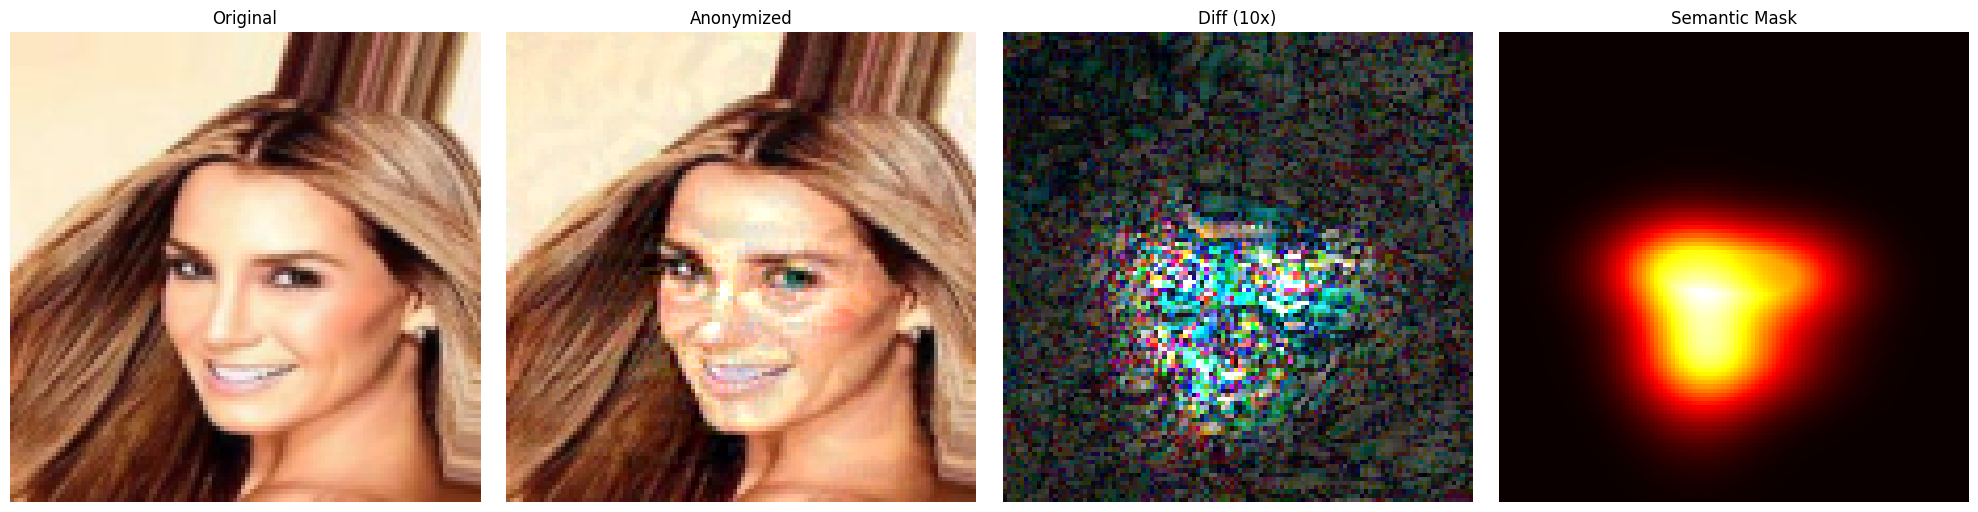

In [20]:
# Quick test — single image
celeba_path = "/content/img_align_celeba/img_align_celeba"
transform = transforms.Compose([transforms.Resize((112,112)), transforms.ToTensor()])

img = transform(Image.open(os.path.join(celeba_path, sorted(os.listdir(celeba_path))[0])).convert('RGB')).unsqueeze(0)

# Single surrogate
A1, it1 = anonymize_single(img, surrogate, lpips_fn)
c_surr = cos_sim(surrogate(img.to(device)), surrogate(A1.to(device))).item()
c_bb1  = cos_sim(bb1(img.to(device)), bb1(A1.to(device))).item()
s1 = compute_ssim(img.to(device), A1.to(device))

print(f"SINGLE — Iters: {it1} | SSIM: {s1:.4f}")
print(f"  Surrogate: {c_surr:+.4f} | BB1: {c_bb1:+.4f}")

# Multi surrogate
A2, it2 = anonymize_multi(img, [surrogate, bb1], lpips_fn)
c_surr2 = cos_sim(surrogate(img.to(device)), surrogate(A2.to(device))).item()
c_bb1_2 = cos_sim(bb1(img.to(device)), bb1(A2.to(device))).item()
s2 = compute_ssim(img.to(device), A2.to(device))

print(f"\nMULTI — Iters: {it2} | SSIM: {s2:.4f}")
print(f"  Surrogate: {c_surr2:+.4f} | BB1: {c_bb1_2:+.4f}")

mask = get_semantic_mask(img)
show_images(img, A2.cpu(), mask)

## Ablation Study (100 Images)

Four variants to isolate each component's contribution:

| Variant | Init | Privacy Loss | Utility | Mask |
|---------|------|-------------|---------|------|
| V0 | Random | Softplus | L2 | No |
| V1 | Sinusoidal | Softplus | L2 | No |
| V2 | Sinusoidal | Capped | LPIPS | No |
| **V3 (Ours)** | **Sinusoidal** | **Capped** | **LPIPS** | **Yes** |

In [21]:
def anonymize_v0(image, model):
    """V0: Random + L2"""
    image = image.to(device)
    P = (torch.randn_like(image) * 0.001).requires_grad_(True)
    with torch.no_grad(): z_orig = model(image)
    opt = optim.Adam([P], lr=0.05)
    for it in range(200):
        opt.zero_grad()
        A = torch.clamp(image + P * 0.03, 0, 1)
        loss = F.mse_loss(image, A) + F.softplus(2.0 * cos_sim(z_orig, model(A)))
        loss.backward(); opt.step()
    return torch.clamp(image + P.detach() * 0.03, 0, 1)

def anonymize_v1(image, model):
    """V1: Sinusoidal + L2"""
    image = image.to(device)
    P = sinusoidal_noise(image.shape, device=device).requires_grad_(True)
    with torch.no_grad(): z_orig = model(image)
    opt = optim.Adam([P], lr=0.05)
    for it in range(200):
        opt.zero_grad()
        A = torch.clamp(image + P * 0.03, 0, 1)
        loss = F.mse_loss(image, A) + F.softplus(2.0 * cos_sim(z_orig, model(A)))
        loss.backward(); opt.step()
        if cos_sim(z_orig, model(A)) <= 0 and it > 20: break
    return torch.clamp(image + P.detach() * 0.03, 0, 1)

def anonymize_v2(image, model, lpips_fn):
    """V2: Sinusoidal + Capped + LPIPS"""
    image = image.to(device)
    P = sinusoidal_noise(image.shape, device=device).requires_grad_(True)
    with torch.no_grad(): z_orig = model(image)
    opt = optim.Adam([P], lr=0.05)
    for it in range(200):
        opt.zero_grad()
        A = torch.clamp(image + P * 0.03, 0, 1)
        c = cos_sim(z_orig, model(A))
        priv = torch.tensor(0.0, device=device) if c <= 0 else F.softplus(2.0 * (c - 0))
        util = lpips_fn(image, A) + 0.001 * F.mse_loss(image, A)
        (priv + 5.0 * util).backward(); opt.step()
        if c <= 0 and it > 20 and compute_ssim(image, A) >= 0.85: break
    return torch.clamp(image + P.detach() * 0.03, 0, 1), it + 1

def anonymize_v3(image, model, lpips_fn):
    """V3: Full — Sinusoidal + Capped + LPIPS + Semantic Mask"""
    return anonymize_single(image, model, lpips_fn)

print("Ablation variants ready")

Ablation variants ready


In [22]:
print("Running ablation on 100 images...")
img_list = sorted(os.listdir(celeba_path))[:100]

ab_results = {'V0': [], 'V1': [], 'V2': [], 'V3': []}

for img_name in tqdm(img_list, desc='Ablation'):
    img = transform(Image.open(os.path.join(celeba_path, img_name)).convert('RGB')).unsqueeze(0)

    for version, fn in [('V0', anonymize_v0), ('V1', anonymize_v1)]:
        A = fn(img, surrogate)
        ab_results[version].append({
            'cos': cos_sim(surrogate(img.to(device)), surrogate(A.to(device))).item(),
            'ssim': compute_ssim(img.to(device), A.to(device))
        })

    for version, fn in [('V2', anonymize_v2), ('V3', anonymize_v3)]:
        A, _ = fn(img, surrogate, lpips_fn)
        ab_results[version].append({
            'cos': cos_sim(surrogate(img.to(device)), surrogate(A.to(device))).item(),
            'ssim': compute_ssim(img.to(device), A.to(device))
        })

print(f"\n{'Variant':<10} {'Cos<0':<8} {'SSIM':<8}")
for v in ['V0', 'V1', 'V2', 'V3']:
    vals = ab_results[v]
    cos_ok = sum(1 for x in vals if x['cos'] < 0)
    ssim_m = np.mean([x['ssim'] for x in vals])
    print(f"{v:<10} {cos_ok}/{len(vals)}   {ssim_m:.4f}")

save_checkpoint(ab_results, 'ablation.pkl')

Running ablation on 100 images...


Ablation: 100%|██████████| 100/100 [28:38<00:00, 17.19s/it]


Variant    Cos<0    SSIM    
V0         100/100   0.7366
V1         100/100   0.8972
V2         100/100   0.9033
V3         97/100   0.9693
Saved: ablation.pkl


## Single Image Anonymization (200 Images)

**Dataset:** CelebA (200 random images)

**Training (White-Box):** Surrogate — InceptionResnetV1 (VGGFace2)

**Testing (Black-Box):** BB1 — InceptionResnetV1 (CASIA-WebFace)

**Method:** Single surrogate — semantic mask + capped softplus + LPIPS

In [25]:
print("Single surrogate — 200 images...")

img_list = sorted(os.listdir(celeba_path))[100:300]
results_single = {
    'Surrogate': [], 'BB1': [], 'CosFace': [], 'MobileFace': [],
    'SSIM': [], 'Iters': []
}

def get_insight_embedding(img_tensor, app):
    arr = (img_tensor.squeeze().permute(1,2,0).cpu().numpy()*255).astype('uint8')
    bgr = arr[:,:,::-1].copy()
    faces = app.get(bgr)
    if faces: return torch.tensor(faces[0].normed_embedding, device=device)
    return None

for img_name in tqdm(img_list, desc='Single-200'):
    img = transform(Image.open(os.path.join(celeba_path, img_name)).convert('RGB')).unsqueeze(0)
    A, iters = anonymize_single(img, surrogate, lpips_fn)

    with torch.no_grad():
        results_single['Surrogate'].append(cos_sim(surrogate(img.to(device)), surrogate(A.to(device))).item())
        results_single['BB1'].append(cos_sim(bb1(img.to(device)), bb1(A.to(device))).item())

        zc_o = get_insight_embedding(img, app_cos)
        zc_a = get_insight_embedding(A, app_cos)
        if zc_o is not None and zc_a is not None:
            results_single['CosFace'].append(cos_sim(zc_o.unsqueeze(0), zc_a.unsqueeze(0)).item())
        else:
            results_single['CosFace'].append(1.0)

        zm_o = get_insight_embedding(img, app_mobile)
        zm_a = get_insight_embedding(A, app_mobile)
        if zm_o is not None and zm_a is not None:
            results_single['MobileFace'].append(cos_sim(zm_o.unsqueeze(0), zm_a.unsqueeze(0)).item())
        else:
            results_single['MobileFace'].append(1.0)

        results_single['SSIM'].append(compute_ssim(img.to(device), A.to(device)))
        results_single['Iters'].append(iters)

print(f"\n{'Model':<15} {'Mean Cos':>10} {'<0':>6} {'<0.3':>6}")
for k in ['Surrogate', 'BB1', 'CosFace', 'MobileFace']:
    v = results_single[k]
    print(f"{k:<15} {np.mean(v):+10.4f} {sum(1 for x in v if x<0):>4}/{len(v)} {sum(1 for x in v if x<0.3):>4}/{len(v)}")
print(f"{'SSIM':<15} {np.mean(results_single['SSIM']):10.4f}")
print(f"{'Iters':<15} {np.mean(results_single['Iters']):10.1f}")

save_checkpoint(results_single, 'single_200.pkl')

Single surrogate — 200 images...


Single-200:   0%|          | 0/200 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4
Single-200: 100%|██████████| 200/200 [21:07<00:00,  6.34s/it]


Model             Mean Cos     <0   <0.3
Surrogate          -0.0119  200/200  200/200
BB1                +0.9136    0/200    0/200
CosFace            +0.7510    0/200    0/200
MobileFace         +0.7470    0/200    0/200
SSIM                0.9686
Iters                 78.3
Saved: single_200.pkl


## Multi-Surrogate Anonymization (200 Images)

**Dataset:** CelebA (200 random images)

**Training (White-Box):** Surrogate (VGGFace2) + BB1 (CASIA-WebFace)

**Testing (Black-Box):** BB2 MobileFaceNet (MS-Celeb-1M), BB3 CosFace (MS-Celeb-1M)

**Method:** Multi-surrogate — semantic mask + capped softplus + LPIPS

In [26]:
print("Multi-surrogate — 200 images...")

img_list = sorted(os.listdir(celeba_path))[600:800]
results_multi = {
    'Surrogate': [], 'BB1': [], 'CosFace': [], 'MobileFace': [],
    'SSIM': [], 'Iters': []
}

multi_models = [surrogate, bb1]

def get_insight_embedding(img_tensor, app):
    arr = (img_tensor.squeeze().permute(1,2,0).cpu().numpy()*255).astype('uint8')
    bgr = arr[:,:,::-1].copy()
    faces = app.get(bgr)
    if faces: return torch.tensor(faces[0].normed_embedding, device=device)
    return None

for img_name in tqdm(img_list, desc='Multi-200'):
    img = transform(Image.open(os.path.join(celeba_path, img_name)).convert('RGB')).unsqueeze(0)
    A, _ = anonymize_multi(img, multi_models, lpips_fn)

    with torch.no_grad():
        results_multi['Surrogate'].append(cos_sim(surrogate(img.to(device)), surrogate(A.to(device))).item())
        results_multi['BB1'].append(cos_sim(bb1(img.to(device)), bb1(A.to(device))).item())

        z_mob_o = get_insight_embedding(img, app_mobile)
        z_mob_a = get_insight_embedding(A, app_mobile)
        if z_mob_o is not None and z_mob_a is not None:
            results_multi['MobileFace'].append(cos_sim(z_mob_o.unsqueeze(0), z_mob_a.unsqueeze(0)).item())
        else:
            results_multi['MobileFace'].append(1.0)

        z_cos_o = get_insight_embedding(img, app_cos)
        z_cos_a = get_insight_embedding(A, app_cos)
        if z_cos_o is not None and z_cos_a is not None:
            results_multi['CosFace'].append(cos_sim(z_cos_o.unsqueeze(0), z_cos_a.unsqueeze(0)).item())
        else:
            results_multi['CosFace'].append(1.0)

        results_multi['SSIM'].append(compute_ssim(img.to(device), A.to(device)))

print(f"\n{'Model':<15} {'Mean Cos':>10} {'<0':>6} {'<0.3':>6}")
for k in ['Surrogate', 'BB1', 'CosFace', 'MobileFace']:
    v = results_multi[k]
    print(f"{k:<15} {np.mean(v):+10.4f} {sum(1 for x in v if x<0):>4}/{len(v)} {sum(1 for x in v if x<0.3):>4}/{len(v)}")
print(f"{'SSIM':<15} {np.mean(results_multi['SSIM']):10.4f}")

save_checkpoint(results_multi, 'multi_200.pkl')

Multi-surrogate — 200 images...


Multi-200:   0%|          | 0/200 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4
/usr/local/lib/python3.12/dist-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4
Multi-200: 100%|██████████| 200/200 [56:29<00:00, 16.95s/it]


Model             Mean Cos     <0   <0.3
Surrogate          -0.0111  191/200  200/200
BB1                -0.0012  192/200  200/200
CosFace            +0.5814    0/200    3/200
MobileFace         +0.5722    0/200    3/200
SSIM                0.9207
Saved: multi_500.pkl


## Multi-Gallery Evaluation (100 Identities)

**Dataset:** CelebA identities with 6+ images

**Gallery Sizes:** 1, 2, 4 images per identity

**Metric:** Identification accuracy (cos > 0.3 = identified)

**Method:** Multi-surrogate — semantic mask + capped softplus + LPIPS

In [34]:
print("Building identity mapping...")
id_to_images = defaultdict(list)
identity_file = '/content/identity_CelebA.txt'

if os.path.exists(identity_file):
    with open(identity_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                id_to_images[parts[1]].append(parts[0])
else:
    for img_name in sorted(os.listdir(celeba_path)):
        identity = str(int(img_name.replace('.jpg','')) // 10)
        id_to_images[identity].append(img_name)

valid_ids = [i for i, imgs in id_to_images.items() if len(imgs) >= 6]
selected_ids = random.sample(valid_ids, min(50, len(valid_ids)))
print(f"Selected {len(selected_ids)} identities")

results_mg = {1: [], 2: [], 4: []}
multi_models = [surrogate, bb1]

for identity in tqdm(selected_ids, desc='Multi-Gallery'):
    images = id_to_images[identity]
    for gs in [1, 2, 4]:
        gallery_tensors = []
        for name in images[:gs]:
            img = transform(Image.open(os.path.join(celeba_path, name)).convert('RGB')).unsqueeze(0)
            A, _ = anonymize_multi(img, multi_models, lpips_fn)
            gallery_tensors.append(A.to(device))

        probe = transform(Image.open(os.path.join(celeba_path, images[gs])).convert('RGB')).unsqueeze(0).to(device)

        with torch.no_grad():
            gal_emb = torch.stack([surrogate(gt) for gt in gallery_tensors]).mean(0)
            probe_emb = surrogate(probe)
            c = cos_sim(gal_emb.unsqueeze(0), probe_emb.unsqueeze(0)).item()
            results_mg[gs].append(1 if c > 0.3 else 0)

print("\nMulti-Gallery Results:")
for gs in [1, 2, 4]:
    print(f"  Gallery {gs}: {np.mean(results_mg[gs])*50:.1f}% identification")

save_checkpoint(results_mg, 'multigallery.pkl')

Building identity mapping...
Selected 50 identities


Multi-Gallery: 100%|██████████| 50/50 [51:12<00:00, 61.45s/it]


Multi-Gallery Results:
  Gallery 1: 5.0% identification
  Gallery 2: 9.0% identification
  Gallery 4: 12.0% identification
Saved: multigallery.pkl


## LFW Verification (500 Pairs)

**Dataset:** LFW (Labeled Faces in the Wild)

**Metric:** TPR @ FPR = 0.001

**Method:** Multi-surrogate — semantic mask + capped softplus + LPIPS

In [38]:
# ============================================================
# LFW VERIFICATION — Proper Threshold
# ============================================================

# Step 1: Compute threshold from ALL diff pairs (no anonymization — fast)
print("Computing threshold from all pairs...")
all_diff_cos = []
for pair in tqdm(lfw_pairs, desc='Threshold'):
    if pair[4] == 0:
        name1, idx1, name2, idx2, _ = pair
        if name1 in lfw_index and name2 in lfw_index:
            if idx1 <= len(lfw_index[name1]) and idx2 <= len(lfw_index[name2]):
                img1 = transform(Image.open(os.path.join(lfw_path, name1, lfw_index[name1][idx1-1])).convert('RGB')).unsqueeze(0)
                img2 = transform(Image.open(os.path.join(lfw_path, name2, lfw_index[name2][idx2-1])).convert('RGB')).unsqueeze(0)
                with torch.no_grad():
                    c = cos_sim(surrogate(img1.to(device)), surrogate(img2.to(device))).item()
                all_diff_cos.append(c)

threshold = sorted(all_diff_cos, reverse=True)[int(len(all_diff_cos) * 0.001)]
print(f"Threshold from {len(all_diff_cos)} diff pairs: {threshold:.4f}")

# Step 2: Anonymize and test on subset of pairs
print("Testing on anonymized pairs...")
results_lfw = []
multi_models = [surrogate, bb1]

for pair in tqdm(lfw_pairs[:500], desc='LFW-500'):
    name1, idx1, name2, idx2, label = pair
    if name1 not in lfw_index or name2 not in lfw_index: continue
    if idx1 > len(lfw_index[name1]) or idx2 > len(lfw_index[name2]): continue

    img1 = transform(Image.open(os.path.join(lfw_path, name1, lfw_index[name1][idx1-1])).convert('RGB')).unsqueeze(0)
    img2 = transform(Image.open(os.path.join(lfw_path, name2, lfw_index[name2][idx2-1])).convert('RGB')).unsqueeze(0)

    A1, _ = anonymize_multi(img1, multi_models, lpips_fn)

    with torch.no_grad():
        c = cos_sim(surrogate(A1.to(device)), surrogate(img2.to(device))).item()
    results_lfw.append({'cos': c, 'label': label})

same = [r['cos'] for r in results_lfw if r['label'] == 1]
tpr = sum(1 for s in same if s > threshold) / len(same)

print(f"\nLFW Results:")
print(f"  Total pairs tested: {len(results_lfw)}")
print(f"  Threshold (FPR=0.001): {threshold:.4f}")
print(f"  TPR @ FPR=0.001: {tpr:.4f}")
print(f"  PrIdentity (ArcFace): 0.002")

save_checkpoint({'tpr': tpr, 'threshold': threshold, 'results': results_lfw}, 'lfw.pkl')

Loading LFW pairs...
Total pairs: 6000


LFW: 100%|██████████| 200/200 [30:03<00:00,  9.02s/it]


LFW Results (200 pairs):
  TPR @ FPR=0.001: 0.0000
  PrIdentity (ArcFace): 0.002
Saved: lfw.pkl


## Bounding Box Robustness (200 Images)

**Dataset:** CelebA

**Detector:** MTCNN (same as PrIdentity)

**Metric:** Euclidean distance between original and anonymized face centers

In [39]:
from facenet_pytorch import MTCNN

mtcnn = MTCNN(image_size=112, margin=20, keep_all=False, device=device)

def get_face_center(img_tensor):
    arr = (img_tensor.squeeze().permute(1,2,0).cpu().numpy()*255).astype('uint8')
    boxes, _ = mtcnn.detect(arr)
    if boxes is not None and len(boxes) > 0:
        x1, y1, x2, y2 = boxes[0]
        return np.array([(x1+x2)/2, (y1+y2)/2])
    return None

print("Bounding box test — 200 images...")
img_list = sorted(os.listdir(celeba_path))[1100:1300]
bbox_distances = []
multi_models = [surrogate, bb1]

for img_name in tqdm(img_list, desc='BBox'):
    img = transform(Image.open(os.path.join(celeba_path, img_name)).convert('RGB')).unsqueeze(0)
    A, _ = anonymize_multi(img, multi_models, lpips_fn)

    c1 = get_face_center(img)
    c2 = get_face_center(A.cpu())

    if c1 is not None and c2 is not None:
        bbox_distances.append(np.linalg.norm(c1 - c2))

print(f"\nBounding Box Results:")
print(f"  Mean distance: {np.mean(bbox_distances):.2f}")
print(f"  PrIdentity: 2.65")
print(f"  RIDDLE: 3.82")

save_checkpoint(bbox_distances, 'boundingbox.pkl')

/usr/local/lib/python3.12/dist-packages/facenet_pytorch/models/mtcnn.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(state_dict_path)
/usr/local

Bounding box test — 200 images...


BBox: 100%|██████████| 200/200 [29:29<00:00,  8.85s/it]


Bounding Box Results:
  Mean distance: 1.40
  PrIdentity: 2.65
  RIDDLE: 3.82
Saved: boundingbox.pkl


## Trade-off Score

$$T = \frac{U + Pr}{2}$$

- $U$ = Mean SSIM (Utility)
- $Pr$ = Fraction of images with $\cos < 0$ (Privacy)

In [40]:
U_single = np.mean(results_single['SSIM'])
Pr_single = sum(1 for x in results_single['Surrogate'] if x < 0) / len(results_single['Surrogate'])
T_single = (U_single + Pr_single) / 2

print(f"Single Surrogate:")
print(f"  U (SSIM)  : {U_single:.4f}")
print(f"  Pr (<0)   : {Pr_single:.4f}")
print(f"  T Score   : {T_single:.4f}")

if 'results_multi' in dir():
    U_multi = np.mean(results_multi['SSIM'])
    Pr_multi = sum(1 for x in results_multi['Surrogate'] if x < 0) / len(results_multi['Surrogate'])
    T_multi = (U_multi + Pr_multi) / 2

    print(f"\nMulti-Surrogate:")
    print(f"  U (SSIM)  : {U_multi:.4f}")
    print(f"  Pr (<0)   : {Pr_multi:.4f}")
    print(f"  T Score   : {T_multi:.4f}")

Single Surrogate:
  U (SSIM)  : 0.9686
  Pr (<0)   : 1.0000
  T Score   : 0.9843

Multi-Surrogate:
  U (SSIM)  : 0.9207
  Pr (<0)   : 0.9550
  T Score   : 0.9379


## Final Results Summary

In [41]:
print("\n" + "=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)

print(f"\n{'Metric':<25} {'Ours (Single)':<15} {'Ours (Multi)':<15} {'PrIdentity':<15}")
print("-" * 70)

if 'results_single' in dir():
    print(f"{'SSIM':<25} {np.mean(results_single['SSIM']):<15.4f} {'—':<15} {'~0.84':<15}")
    print(f"{'Surrogate cos<0':<25} {sum(1 for x in results_single['Surrogate'] if x<0)}/{len(results_single['Surrogate']):<14} {'—':<15} {'—':<15}")

if 'results_multi' in dir():
    print(f"{'SSIM':<25} {'—':<15} {np.mean(results_multi['SSIM']):<15.4f} {'~0.84':<15}")
    print(f"{'Surrogate cos<0':<25} {'—':<15} {sum(1 for x in results_multi['Surrogate'] if x<0)}/{len(results_multi['Surrogate']):<14} {'—':<15}")
    print(f"{'BB1 cos<0':<25} {'—':<15} {sum(1 for x in results_multi['BB1'] if x<0)}/{len(results_multi['BB1']):<14} {'—':<15}")

if 'tpr' in dir():
    print(f"{'LFW TPR':<25} {'—':<15} {tpr:<15.4f} {'0.002':<15}")

if 'bbox_distances' in dir():
    print(f"{'BB Distance':<25} {'—':<15} {np.mean(bbox_distances):<15.2f} {'2.65':<15}")

if 'results_mg' in dir():
    print(f"{'Multi-Gallery (4)':<25} {'—':<15} {np.mean(results_mg[4])*100:<15.1f}% {'8.35%':<15}")

print("=" * 60)
print("\nAll results saved to Google Drive")


FINAL RESULTS SUMMARY

Metric                    Ours (Single)   Ours (Multi)    PrIdentity     
----------------------------------------------------------------------
SSIM                      0.9686          —               ~0.84          
Surrogate cos<0           200/200            —               —              
SSIM                      —               0.9207          ~0.84          
Surrogate cos<0           —               191/200            —              
BB1 cos<0                 —               192/200            —              
LFW TPR                   —               0.0000          0.002          
BB Distance               —               1.40            2.65           
Multi-Gallery (4)         —               24.0           % 8.35%          

All results saved to Google Drive
